<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/catsVsdogs_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [19]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
!pip install -q -U kaggle

In [21]:
!kaggle datasets list -s dogs-vs-cats

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token
Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, gener

In [22]:
import os

url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

!wget -q --show-progress "$url" -O /content/cats_and_dogs.zip

print("Download complete!")
print("File size:", os.path.getsize("/content/cats_and_dogs.zip") / (1024**2), "MB")

/content/cats_and_d 100%[===================>] 786.67M  69.9MB/s    in 11s     
Download complete!
File size: 786.6736183166504 MB


In [23]:
import zipfile
import os

zip_path = "/content/cats_and_dogs.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction complete!")
print(os.listdir("/content/PetImages"))

Extraction complete!
['Dog', 'Cat']


In [24]:
import os

cat_count = len(os.listdir("/content/PetImages/Cat"))
dog_count = len(os.listdir("/content/PetImages/Dog"))

print("Cats:", cat_count)
print("Dogs:", dog_count)

Cats: 12501
Dogs: 12501


In [25]:
import os
from PIL import Image

data_dir = "/content/PetImages"

removed = 0

for category in ["Cat", "Dog"]:
    folder = os.path.join(data_dir, category)

    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)

        try:
            img = Image.open(filepath)
            img.verify()
        except:
            print("Removing:", filepath)
            os.remove(filepath)
            removed += 1

print("Total corrupted images removed:", removed)

Removing: /content/PetImages/Cat/Thumbs.db
Removing: /content/PetImages/Cat/666.jpg
Removing: /content/PetImages/Dog/Thumbs.db
Removing: /content/PetImages/Dog/11702.jpg
Total corrupted images removed: 4


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [26]:
cat_count = len(os.listdir("/content/PetImages/Cat"))
dog_count = len(os.listdir("/content/PetImages/Dog"))

print("Cats:", cat_count)
print("Dogs:", dog_count)
print("Total:", cat_count + dog_count)

Cats: 12499
Dogs: 12499
Total: 24998


In [27]:
import tensorflow as tf

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/PetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/PetImages",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_ds.class_names)



Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
Classes: ['Cat', 'Dog']


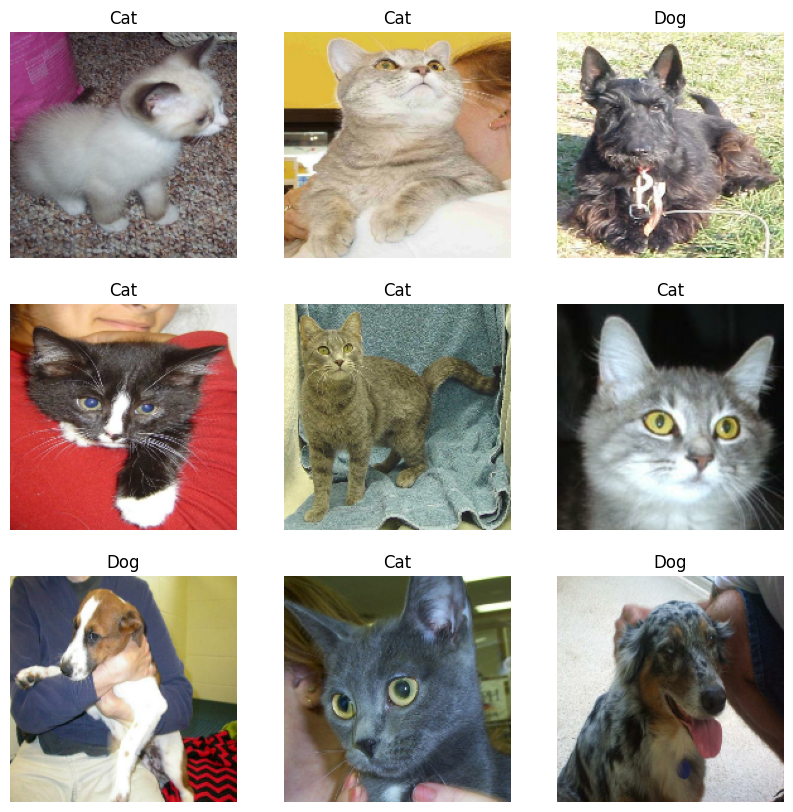

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [29]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.cache().prefetch(
    buffer_size=AUTOTUNE
)

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [31]:
model=Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(180, 180, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     5,308,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,550,273 (21.17 MB)

 Trainable params: 5,550,273 (21.17 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [33]:
import os
from PIL import Image

data_dir = "/content/PetImages"

removed = 0

for category in ["Cat", "Dog"]:
    folder = os.path.join(data_dir, category)

    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)

        try:
            with Image.open(filepath) as img:
                # Image ko actually load karo
                img.load()

                # Sirf RGB/RGBA/grayscale images allow karo
                if img.mode not in ["RGB", "RGBA", "L"]:
                    print("Removing invalid mode:", filepath, img.mode)
                    os.remove(filepath)
                    removed += 1

        except Exception as e:
            print("Removing corrupted image:", filepath)
            os.remove(filepath)
            removed += 1

print("Total images removed:", removed)

Removing invalid mode: /content/PetImages/Cat/10501.jpg P
Removing invalid mode: /content/PetImages/Cat/11210.jpg P
Removing invalid mode: /content/PetImages/Cat/5370.jpg P
Removing invalid mode: /content/PetImages/Cat/11095.jpg P
Removing invalid mode: /content/PetImages/Cat/4833.jpg P
Removing invalid mode: /content/PetImages/Cat/9171.jpg P
Removing invalid mode: /content/PetImages/Cat/11935.jpg P
Removing invalid mode: /content/PetImages/Cat/11874.jpg P
Removing invalid mode: /content/PetImages/Cat/11565.jpg P
Removing invalid mode: /content/PetImages/Cat/850.jpg P
Removing invalid mode: /content/PetImages/Cat/936.jpg P
Removing invalid mode: /content/PetImages/Cat/7968.jpg P
Removing invalid mode: /content/PetImages/Cat/140.jpg P
Removing invalid mode: /content/PetImages/Cat/3300.jpg P
Removing invalid mode: /content/PetImages/Cat/8470.jpg P
Removing invalid mode: /content/PetImages/Cat/10125.jpg P
Removing invalid mode: /content/PetImages/Cat/6435.jpg P
Removing invalid mode: /con

In [34]:
import os
from PIL import Image

source_dir = "/content/PetImages"
clean_dir = "/content/CleanPetImages"

os.makedirs(clean_dir, exist_ok=True)

for category in ["Cat", "Dog"]:
    os.makedirs(os.path.join(clean_dir, category), exist_ok=True)

good = 0
bad = 0

for category in ["Cat", "Dog"]:
    source_folder = os.path.join(source_dir, category)
    target_folder = os.path.join(clean_dir, category)

    for filename in os.listdir(source_folder):

        source_path = os.path.join(source_folder, filename)

        try:
            with Image.open(source_path) as img:

                # Force image to RGB (3 channels)
                img = img.convert("RGB")

                # Save as JPEG
                new_filename = os.path.splitext(filename)[0] + ".jpg"
                target_path = os.path.join(target_folder, new_filename)

                img.save(target_path, "JPEG")

                good += 1

        except Exception as e:
            bad += 1

print("Clean images:", good)
print("Bad images skipped:", bad)

Clean images: 24938
Bad images skipped: 0


In [35]:
print("Cats:", len(os.listdir("/content/CleanPetImages/Cat")))
print("Dogs:", len(os.listdir("/content/CleanPetImages/Dog")))

Cats: 12473
Dogs: 12465


In [36]:
import tensorflow as tf

IMG_SIZE = (180, 180)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/CleanPetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/CleanPetImages",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

print("Classes:", train_ds.class_names)

Found 24938 files belonging to 2 classes.
Using 19951 files for training.
Found 24938 files belonging to 2 classes.
Using 4987 files for validation.
Classes: ['Cat', 'Dog']


In [37]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 180, 180, 3)
Label batch shape: (32,)


In [38]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

In [39]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
import os
from PIL import Image

source_dir = "/content/PetImages"
clean_dir = "/content/CleanPetImages"

os.makedirs(clean_dir, exist_ok=True)

for category in ["Cat", "Dog"]:
    os.makedirs(os.path.join(clean_dir, category), exist_ok=True)

good = 0
bad = 0

for category in ["Cat", "Dog"]:
    source_folder = os.path.join(source_dir, category)
    target_folder = os.path.join(clean_dir, category)

    for filename in os.listdir(source_folder):
        source_path = os.path.join(source_folder, filename)

        try:
            with Image.open(source_path) as img:
                img = img.convert("RGB")

                new_filename = os.path.splitext(filename)[0] + ".jpg"
                target_path = os.path.join(target_folder, new_filename)

                img.save(target_path, "JPEG", quality=85)

                good += 1

        except:
            bad += 1

print("Good:", good)
print("Bad:", bad)

Good: 24938
Bad: 0


In [42]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/CleanPetImages",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/CleanPetImages",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

print(train_ds.class_names)

Found 24938 files belonging to 2 classes.
Using 19951 files for training.
Found 24938 files belonging to 2 classes.
Using 4987 files for validation.
['Cat', 'Dog']


In [43]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [44]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.6551 - loss: 0.6110 - val_accuracy: 0.7580 - val_loss: 0.5027
Epoch 2/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7688 - loss: 0.4875 - val_accuracy: 0.7846 - val_loss: 0.4637
Epoch 3/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.8089 - loss: 0.4246 - val_accuracy: 0.8137 - val_loss: 0.4147
Epoch 4/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.8326 - loss: 0.3777 - val_accuracy: 0.8286 - val_loss: 0.3838
Epoch 5/5
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.8560 - loss: 0.3305 - val_accuracy: 0.8336 - val_loss: 0.3752


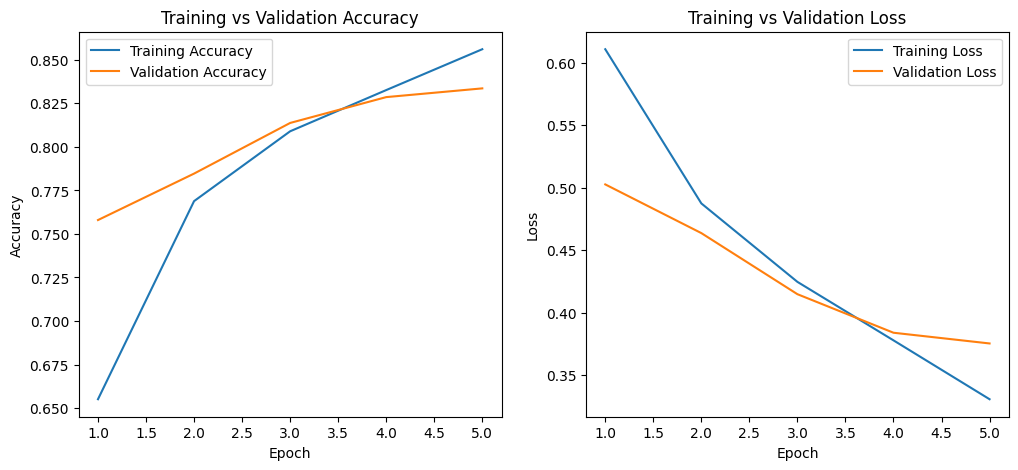

In [46]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")

plt.show()

In [47]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8336 - loss: 0.3752
Validation Loss: 0.3752302825450897
Validation Accuracy: 0.8335672616958618


In [48]:
model.save("/content/cats_dogs_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [49]:
from google.colab import files

uploaded = files.upload()


Saving dogssssssssa.avif to dogssssssssa (2).avif


In [51]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

filename = list(uploaded.keys())[0]

img = load_img(
    filename,
    target_size=(128, 128)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array, verbose=0)[0][0]

if prediction >= 0.5:
    print("Prediction: DOG 🐶")
    print(f"Confidence: {prediction * 100:.2f}%")
else:
    print("Prediction: CAT 🐱")
    print(f"Confidence: {(1 - prediction) * 100:.2f}%")

Prediction: CAT 🐱
Confidence: 98.72%
